In [1]:
!pip install dagshub mlflow xgboost scikit-learn pandas numpy matplotlib seaborn scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 76.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
os.environ['MLFLOW_TRACKING_USERNAME'] = 'sophyrise'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '95f86824d28eb66b760d891dfa5f39816ddea9c4'

import dagshub
dagshub.init(repo_owner='sophyrise', repo_name='house-prices-mlflow', mlflow=True)

import mlflow
mlflow.set_experiment("house-prices-experiment-main")
print("MLflow tracking URI:", mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=7e0c7dcf-d207-4157-b965-2f8e6255d67a&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=90b280913822871d13b52640918574350bff86e9d60e19d6da20cb1fbb653a67




Output()

Accessing as sophyrise

Initialized MLflow to track repo "sophyrise/house-prices-mlflow"

Repository sophyrise/house-prices-mlflow initialized!

MLflow tracking URI: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow


In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/sopogurjishvili/house-prices-data/sample_submission.csv
/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv
/kaggle/input/datasets/sopogurjishvili/house-prices-data/test.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import skew
from scipy.stats import pearsonr
from xgboost import XGBRegressor

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print('All imports OK')

All imports OK


In [16]:
train = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv')
test  = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/test.csv')

print('Train shape:', train.shape)
print('Test shape: ', test.shape)
train.head()

Train shape: (1460, 81)
Test shape:  (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
# Missing value analysis
missing     = train.isnull().sum()
missing_pct = (missing / len(train)) * 100
missing_df  = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df  = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)
print(missing_df)

              count        pct
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247
BsmtCond         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


In [18]:
# DATA CLEANING

In [19]:
cols_to_drop = missing_df[missing_df['pct'] > 80].index.tolist()
train.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)
print('Dropped columns:', cols_to_drop)

train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 200000))].reset_index(drop=True)
print('Train after outlier removal:', train.shape)

train['SalePrice'] = np.log1p(train['SalePrice'])

all_data = pd.concat([train.drop('SalePrice', axis=1), test], axis=0).reset_index(drop=True)
print('Combined shape:', all_data.shape)

Dropped columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Train after outlier removal: (1458, 77)
Combined shape: (2917, 76)


In [20]:
print(train.shape)
print(train.columns.tolist())

(1458, 77)
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscV

In [21]:
# FEATURE ENGINEERING

In [22]:
none_cols = ['MasVnrType', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in none_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna('None')

zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
             'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(0)

mode_cols = ['MSZoning', 'Electrical', 'KitchenQual',
             'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']
for col in mode_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

for col in all_data.columns:
    if all_data[col].isnull().sum() > 0:
        if all_data[col].dtype == 'object':
            all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
        else:
            all_data[col] = all_data[col].fillna(0)

print('Remaining NaNs:', all_data.isnull().sum().sum())

Remaining NaNs: 0


In [23]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

all_data['TotalBath'] = (all_data['FullBath'] + 0.5 * all_data['HalfBath'] +
                         all_data['BsmtFullBath'] + 0.5 * all_data['BsmtHalfBath'])

all_data['HouseAge'] = all_data['YrSold'] - all_data['YearBuilt']

all_data['RemodelAge'] = all_data['YrSold'] - all_data['YearRemodAdd']

all_data['HasGarage']   = (all_data['GarageArea']   > 0).astype(int)
all_data['HasBsmt']     = (all_data['TotalBsmtSF']  > 0).astype(int)
all_data['Has2ndFloor'] = (all_data['2ndFlrSF']     > 0).astype(int)

all_data['QualCond'] = all_data['OverallQual'] * all_data['OverallCond']

all_data['PorchSF'] = (all_data['OpenPorchSF'] + all_data['EnclosedPorch'] +
                       all_data['3SsnPorch']   + all_data['ScreenPorch'])

print('Shape after feature engineering:', all_data.shape)

Shape after feature engineering: (2917, 85)


In [24]:
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
for col in qual_cols:
    if col in all_data.columns:
        all_data[col] = all_data[col].map(quality_map).fillna(0)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = all_data.select_dtypes(include='object').columns.tolist()
print('Categorical columns to label-encode:', cat_cols)
for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print('Shape:', all_data.shape)
print('Any remaining objects:', all_data.select_dtypes(include='object').shape[1])

Categorical columns to label-encode: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']
Shape: (2917, 85)
Any remaining objects: 0


In [25]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns.tolist()
skewed_feats  = all_data[numeric_cols].apply(lambda x: skew(x.dropna()))
skewed_feats  = skewed_feats[abs(skewed_feats) > 0.75].index.tolist()
all_data[skewed_feats] = np.log1p(all_data[skewed_feats].clip(lower=0))
print(f'Log-transformed {len(skewed_feats)} skewed features')

Log-transformed 51 skewed features


In [26]:
# FEATURE SELECTION

In [27]:
n_train = len(train)
X_all   = all_data[:n_train].copy()
y_all   = train['SalePrice'].values
X_kaggle_full = all_data[n_train:].copy()

if 'Id' in X_all.columns:
    X_all = X_all.drop(columns=['Id'])
    X_kaggle_full = X_kaggle_full.drop(columns=['Id'])

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape, '| X_val:', X_val.shape)

X_train: (1166, 84) | X_val: (292, 84)


In [28]:
# FEATURE SELECTION

In [29]:
# --- STEP 1: SelectKBest sweep ---
mlflow.set_experiment('feature_selection_experiments')

for k in [5, 10, 15, 20, 25, 30, 40, 50, 60, 75]:
    k = min(k, X_train.shape[1])
    selector = SelectKBest(f_regression, k=k)
    selector.fit(X_train, y_train)
    selected = X_train.columns[selector.get_support()].tolist()
    model_test = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model_test.fit(X_train[selected], y_train)
    train_r = rmse(y_train, model_test.predict(X_train[selected]))
    val_r   = rmse(y_val,   model_test.predict(X_val[selected]))
    with mlflow.start_run(run_name=f'SelectKBest_k{k}'):
        mlflow.log_param('method', 'SelectKBest')
        mlflow.log_param('k', k)
        mlflow.log_metric('train_rmse', train_r)
        mlflow.log_metric('val_rmse', val_r)
        mlflow.log_metric('overfit_gap', val_r - train_r)
        print(f'k={k}: train={train_r:.4f} val={val_r:.4f}')

# საუკეთესო k პოვნა
fs_runs = mlflow.search_runs(experiment_names=['feature_selection_experiments'])
fs_runs = fs_runs[fs_runs['tags.mlflow.runName'].str.startswith('SelectKBest')]
fs_runs = fs_runs.dropna(subset=['metrics.val_rmse', 'metrics.train_rmse'])
fs_runs['k'] = fs_runs['params.k'].astype(int)
fs_runs = fs_runs.sort_values('k')
best_k = int(fs_runs.loc[fs_runs['metrics.val_rmse'].idxmin(), 'k'])
print(f'საუკეთესო k: {best_k}')

# SelectKBest საუკეთესო k-ით
kbest_selector = SelectKBest(f_regression, k=best_k)
kbest_selector.fit(X_train, y_train)
kbest_features = X_train.columns[kbest_selector.get_support()].tolist()
print(f'SelectKBest features: {len(kbest_features)}')

k=5: train=0.1277 val=0.1646
🏃 View run SelectKBest_k5 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/dc6b0b9da589498a8d9864fd711bdfb5
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=10: train=0.1099 val=0.1586
🏃 View run SelectKBest_k10 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/4fee59b286774bc2b451807297ecf3ad
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=15: train=0.0966 val=0.1410
🏃 View run SelectKBest_k15 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/908fc4532aa3412b8f7a715849f630be
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=20: train=0.0941 val=0.1402
🏃 View run SelectKBest_k20 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/3ec5a6abf61a49c1a9bd93223ea66d80
🧪 View experiment at: https:/

In [30]:
# --- STEP 2: კორელაციის threshold sweep ---
mlflow.set_experiment('feature_selection_experiments')

best_corr_threshold = 0.85
best_corr_val = float('inf')
features_after_corr_best = kbest_features

for threshold in [0.80, 0.85, 0.90]:
    corr_matrix = X_train[kbest_features].corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    corr_to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    features_after_corr = [f for f in kbest_features if f not in corr_to_drop]

    model_test = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model_test.fit(X_train[features_after_corr], y_train)
    train_r = rmse(y_train, model_test.predict(X_train[features_after_corr]))
    val_r   = rmse(y_val,   model_test.predict(X_val[features_after_corr]))

    with mlflow.start_run(run_name=f'CorrFilter_threshold_{threshold}'):
        mlflow.log_param('method', 'CorrelationFilter')
        mlflow.log_param('threshold', threshold)
        mlflow.log_metric('n_dropped', len(corr_to_drop))
        mlflow.log_metric('n_remaining', len(features_after_corr))
        mlflow.log_metric('train_rmse', train_r)
        mlflow.log_metric('val_rmse', val_r)
        mlflow.log_metric('overfit_gap', val_r - train_r)
        print(f'threshold={threshold}: dropped={len(corr_to_drop)} remaining={len(features_after_corr)} val={val_r:.4f}')

    if val_r < best_corr_val:
        best_corr_val = val_r
        best_corr_threshold = threshold
        features_after_corr_best = features_after_corr

print(f'საუკეთესო threshold: {best_corr_threshold} → {len(features_after_corr_best)} feature')
features_after_corr = features_after_corr_best

threshold=0.8: dropped=13 remaining=47 val=0.1190
🏃 View run CorrFilter_threshold_0.8 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/0a32f26371b14b108d5d00571ec66c19
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
threshold=0.85: dropped=11 remaining=49 val=0.1163
🏃 View run CorrFilter_threshold_0.85 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/876c8dec480540ff9fc5750a55ca2419
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
threshold=0.9: dropped=7 remaining=53 val=0.1176
🏃 View run CorrFilter_threshold_0.9 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/0b9067ea2edf40d0b43c31adf308889c
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
საუკეთესო threshold: 0.85 → 49 feature


In [32]:
# STEP 3
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
mlflow.set_experiment('feature_selection_experiments')

best_rfe_n = 25
best_rfe_val = float('inf')
final_features = features_after_corr[:25]

for n in [20, 22, 25]:
    n = min(n, len(features_after_corr))
    rfe_sel = RFE(estimator=Ridge(alpha=1.0), n_features_to_select=n, step=1)
    rfe_sel.fit(X_train[features_after_corr], y_train)
    selected = X_train[features_after_corr].columns[rfe_sel.get_support()].tolist()

    model_test = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model_test.fit(X_train[selected], y_train)
    train_r = rmse(y_train, model_test.predict(X_train[selected]))
    val_r   = rmse(y_val,   model_test.predict(X_val[selected]))

    with mlflow.start_run(run_name=f'RFE_n{n}'):
        mlflow.log_param('method', 'RFE')
        mlflow.log_param('n_features_to_select', n)
        mlflow.log_metric('train_rmse', train_r)
        mlflow.log_metric('val_rmse', val_r)
        mlflow.log_metric('overfit_gap', val_r - train_r)
        print(f'RFE n={n}: train={train_r:.4f} val={val_r:.4f}')

    if val_r < best_rfe_val:
        best_rfe_val = val_r
        best_rfe_n = n
        final_features = selected

print(f'\nსაუკეთესო RFE n: {best_rfe_n}')
print(f'საბოლოო feature რაოდენობა: {len(final_features)}')
print(f'საბოლოო features: {final_features}')


RFE n=20: train=0.0964 val=0.1392
🏃 View run RFE_n20 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/5a927c6b163547e8aec7483fa3475505
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
RFE n=22: train=0.0945 val=0.1382
🏃 View run RFE_n22 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/6d611a458e6f46d49c1079c161e2d8ad
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
RFE n=25: train=0.0943 val=0.1367
🏃 View run RFE_n25 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/2cb99609f5754f38a7818b82580fd7de
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9

საუკეთესო RFE n: 25
საბოლოო feature რაოდენობა: 25
საბოლოო features: ['LotFrontage', 'LotArea', 'Condition1', 'OverallQual', 'RoofStyle', 'ExterQual', 'Foundation', 'BsmtQual', 'BsmtExposure', 'Heating', 'Heatin

RFE + Ridge val RMSE: 0.1368
RFE + GBM val RMSE: 0.1367


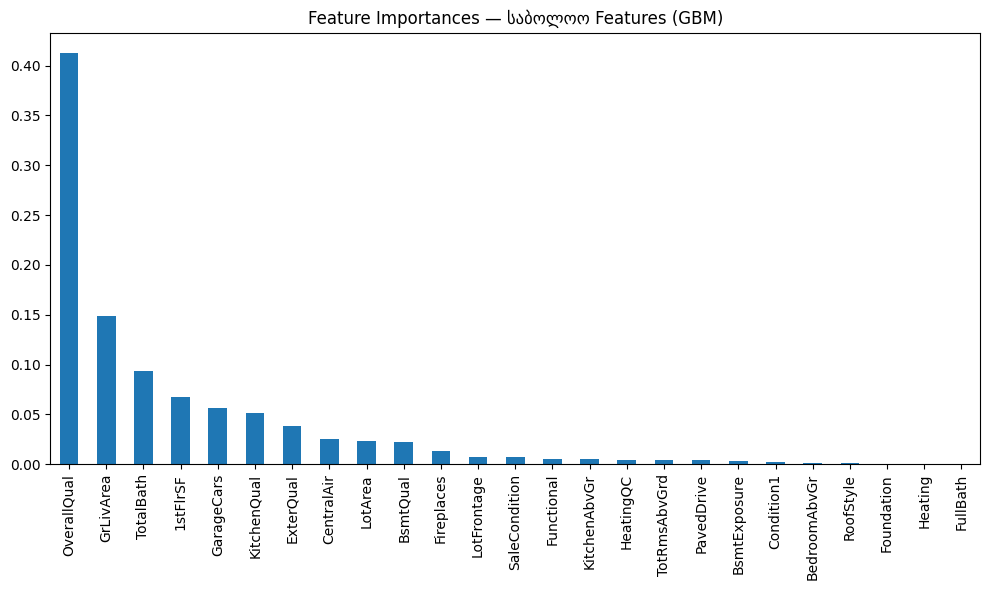

In [33]:
rfe_check = RFE(estimator=Ridge(alpha=1.0), n_features_to_select=25, step=1)
rfe_check.fit(X_train[features_after_corr], y_train)
selected_rfe = X_train[features_after_corr].columns[rfe_check.get_support()].tolist()

ridge_check = Ridge(alpha=1.0)
ridge_check.fit(X_train[selected_rfe], y_train)
val_r = rmse(y_val, ridge_check.predict(X_val[selected_rfe]))
print(f'RFE + Ridge val RMSE: {val_r:.4f}')

gbm_check = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
gbm_check.fit(X_train[selected_rfe], y_train)
val_r2 = rmse(y_val, gbm_check.predict(X_val[selected_rfe]))
print(f'RFE + GBM val RMSE: {val_r2:.4f}')

quick_gbm = GradientBoostingRegressor(n_estimators=100, max_depth=3,
                                       learning_rate=0.1, random_state=42)
quick_gbm.fit(X_train[final_features], y_train)
feat_imp = pd.Series(quick_gbm.feature_importances_, index=final_features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar')
plt.title('Feature Importances — საბოლოო Features (GBM)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [34]:
# Prepare final train/val/test sets
X_train_sel  = X_train[final_features]
X_val_sel    = X_val[final_features]
X_test_final = X_kaggle_full[final_features]

print('X_train_sel:', X_train_sel.shape)
print('X_val_sel:  ', X_val_sel.shape)
print('X_test_final:', X_test_final.shape)
print('NaNs in test:', X_test_final.isnull().sum().sum())

X_train_sel: (1166, 25)
X_val_sel:   (292, 25)
X_test_final: (1459, 25)
NaNs in test: 0


In [35]:
# Cross-validation setup — used for all experiments
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def log_cv_and_test(model, model_name, params, run_name, experiment_name, note=''):
    mlflow.set_experiment(experiment_name)
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag('model_type', model_name)
        if note:
            mlflow.set_tag('note', note)
        mlflow.log_params(params)
        mlflow.log_param('n_features', len(final_features))

        cv_results = cross_validate(
            model, X_train_sel, y_train,
            cv=kf,
            scoring={
                'rmse': 'neg_root_mean_squared_error',
                'mae':  'neg_mean_absolute_error',
                'r2':   'r2'
            },
            return_train_score=True
        )

        train_rmse = -cv_results['train_rmse'].mean()
        val_rmse   = -cv_results['test_rmse'].mean()
        train_mae  = -cv_results['train_mae'].mean()
        val_mae    = -cv_results['test_mae'].mean()
        train_r2   =  cv_results['train_r2'].mean()
        val_r2     =  cv_results['test_r2'].mean()

        mlflow.log_metric('train_rmse',   train_rmse)
        mlflow.log_metric('val_rmse',     val_rmse)
        mlflow.log_metric('train_mae',    train_mae)
        mlflow.log_metric('val_mae',      val_mae)
        mlflow.log_metric('train_r2',     train_r2)
        mlflow.log_metric('val_r2',       val_r2)
        mlflow.log_metric('overfit_gap',  val_rmse - train_rmse)

        model.fit(X_train_sel, y_train)
        val_preds   = model.predict(X_val_sel)
        mlflow.log_metric('holdout_val_rmse', rmse(y_val, val_preds))
        mlflow.log_metric('holdout_val_mae',  mean_absolute_error(y_val, val_preds))
        mlflow.log_metric('holdout_val_r2',   r2_score(y_val, val_preds))

        with open('model.pkl', 'wb') as f:
            pickle.dump(model, f)
        mlflow.log_artifact('model.pkl')

        print(f'{run_name} | cv_val_rmse={val_rmse:.4f} | holdout_val_rmse={rmse(y_val,val_preds):.4f} | note={note}')

print('Helper function ready.')

Helper function ready.


In [24]:
# TRAINING

In [25]:
# ElasticNet — Ridge + Lasso კომბინაცია
from sklearn.linear_model import ElasticNet

elasticnet_params = [
    {'alpha': 0.001, 'l1_ratio': 0.1},
    {'alpha': 0.001, 'l1_ratio': 0.5},
    {'alpha': 0.001, 'l1_ratio': 0.9},
    {'alpha': 0.01,  'l1_ratio': 0.1},
    {'alpha': 0.01,  'l1_ratio': 0.5},
    {'alpha': 0.01,  'l1_ratio': 0.9},
    {'alpha': 0.1,   'l1_ratio': 0.1},
    {'alpha': 0.1,   'l1_ratio': 0.5},
    {'alpha': 0.1,   'l1_ratio': 0.9},
    {'alpha': 1.0,   'l1_ratio': 0.1},
    {'alpha': 1.0,   'l1_ratio': 0.5},
    {'alpha': 1.0,   'l1_ratio': 0.9},
]

for p in elasticnet_params:
    if p['alpha'] > 0.5:
        note = 'strong_regularization'
    elif p['alpha'] < 0.005:
        note = 'weak_regularization'
    else:
        note = 'ok'

    model = ElasticNet(alpha=p['alpha'], l1_ratio=p['l1_ratio'], max_iter=10000)
    log_cv_and_test(
        model, 'ElasticNet',
        {'model': 'ElasticNet', 'alpha': p['alpha'], 'l1_ratio': p['l1_ratio']},
        run_name=f"EN_a{p['alpha']}_l1{p['l1_ratio']}",
        experiment_name='elasticnet',
        note=note
    )

2026/04/12 13:23:02 INFO mlflow.tracking.fluent: Experiment with name 'elasticnet' does not exist. Creating a new experiment.


EN_a0.001_l10.1 | cv_val_rmse=0.1289 | holdout_val_rmse=0.1368 | note=weak_regularization
🏃 View run EN_a0.001_l10.1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14/runs/7e317d73f68d4c02b33b447ccd4314a0
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14
EN_a0.001_l10.5 | cv_val_rmse=0.1293 | holdout_val_rmse=0.1368 | note=weak_regularization
🏃 View run EN_a0.001_l10.5 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14/runs/19be07b7ce50481e95bb1afa107ee306
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14
EN_a0.001_l10.9 | cv_val_rmse=0.1301 | holdout_val_rmse=0.1372 | note=weak_regularization
🏃 View run EN_a0.001_l10.9 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14/runs/0a5bc16f82a04101a1ffea24b75324cc
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/14
EN_a0.01_l10.

In [26]:
# Ridge Regression

ridge_alphas = [
    0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20, 50,
    100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000
]

for alpha in ridge_alphas:
    if alpha < 1:
        note = 'weak_regularization'
    elif alpha > 10000:
        note = 'strong_regularization_underfitting'
    else:
        note = 'ok'
    model = Ridge(alpha=alpha)
    params = {'model': 'Ridge', 'alpha': alpha}
    log_cv_and_test(model, 'Ridge', params,
                    run_name=f'Ridge_alpha{alpha}',
                    experiment_name='ridge_regression',
                    note=note)

Ridge_alpha0.01 | cv_val_rmse=0.1290 | holdout_val_rmse=0.1369 | note=weak_regularization
🏃 View run Ridge_alpha0.01 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3/runs/431283daf81240deafcb0a6b3e3599aa
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3
Ridge_alpha0.05 | cv_val_rmse=0.1289 | holdout_val_rmse=0.1369 | note=weak_regularization
🏃 View run Ridge_alpha0.05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3/runs/1dae9a67af914909ae207e71a6d59e31
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3
Ridge_alpha0.1 | cv_val_rmse=0.1289 | holdout_val_rmse=0.1369 | note=weak_regularization
🏃 View run Ridge_alpha0.1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3/runs/e44654520e7b40ce88c9d642d1e339d0
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/3
Ridge_alpha0.5 | cv_v

In [27]:
# Lasso Regression

lasso_alphas = [
    0.000005, 0.00001, 0.00005, 0.0001, 0.0005,
    0.001, 0.005, 0.01, 0.05, 0.1,
    0.2, 0.3, 0.5, 0.7, 1.0,
    2.0, 5.0, 10.0, 20.0, 50.0, 100.0
]

for alpha in lasso_alphas:
    if alpha < 0.0001:
        note = 'very_weak_regularization'
    elif alpha > 5.0:
        note = 'strong_regularization_underfitting'
    else:
        note = 'ok'
    model = Lasso(alpha=alpha, max_iter=10000)
    params = {'model': 'Lasso', 'alpha': alpha}
    log_cv_and_test(model, 'Lasso', params,
                    run_name=f'Lasso_alpha{alpha}',
                    experiment_name='lasso_regression',
                    note=note)

Lasso_alpha5e-06 | cv_val_rmse=0.1290 | holdout_val_rmse=0.1369 | note=very_weak_regularization
🏃 View run Lasso_alpha5e-06 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/4/runs/c3045f7a954142149ee558339b4a05a4
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/4
Lasso_alpha1e-05 | cv_val_rmse=0.1290 | holdout_val_rmse=0.1369 | note=very_weak_regularization
🏃 View run Lasso_alpha1e-05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/4/runs/e901fd7d7a0a41b886f2d2e6a6762945
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/4
Lasso_alpha5e-05 | cv_val_rmse=0.1289 | holdout_val_rmse=0.1368 | note=very_weak_regularization
🏃 View run Lasso_alpha5e-05 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/4/runs/caa3d0cbe34f4e90acf43e478dc383ae
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/

In [28]:
# Decision Trees

dt_params_list = [
    {'max_depth': 2,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 2,    'min_samples_split': 10, 'min_samples_leaf': 5},
    {'max_depth': 3,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 3,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 3,    'min_samples_split': 10, 'min_samples_leaf': 5},
    {'max_depth': 4,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 4,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 5,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 5,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 5,    'min_samples_split': 10, 'min_samples_leaf': 4},
    {'max_depth': 5,    'min_samples_split': 20, 'min_samples_leaf': 5},
    {'max_depth': 6,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 6,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 6,    'min_samples_split': 10, 'min_samples_leaf': 4},
    {'max_depth': 8,    'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 8,    'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 10,   'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': 10,   'min_samples_split': 5,  'min_samples_leaf': 2},
    {'max_depth': 10,   'min_samples_split': 10, 'min_samples_leaf': 4},
    {'max_depth': None, 'min_samples_split': 2,  'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 5},
]

for p in dt_params_list:
    depth = p['max_depth']
    if depth is not None and depth <= 3:
        note = 'underfitting'
    elif depth is None or depth >= 8:
        note = 'overfitting'
    else:
        note = 'ok'

    model = DecisionTreeRegressor(random_state=42, **p)
    params = {'model': 'DecisionTree', **p, 'max_depth': str(depth)}
    run_name = f"DT_depth{depth}_split{p['min_samples_split']}_leaf{p['min_samples_leaf']}"
    log_cv_and_test(model, 'DecisionTree', params, run_name,
                    experiment_name='decision_tree', note=note)

DT_depth2_split2_leaf1 | cv_val_rmse=0.2557 | holdout_val_rmse=0.2488 | note=underfitting
🏃 View run DT_depth2_split2_leaf1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/5/runs/822a6ad0e8234589b97c32901fa87518
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/5
DT_depth2_split10_leaf5 | cv_val_rmse=0.2557 | holdout_val_rmse=0.2488 | note=underfitting
🏃 View run DT_depth2_split10_leaf5 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/5/runs/5349780318bc4365a697035ab5dd6dbd
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/5
DT_depth3_split2_leaf1 | cv_val_rmse=0.2267 | holdout_val_rmse=0.2214 | note=underfitting
🏃 View run DT_depth3_split2_leaf1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/5/runs/9afc3f14fb40414ab420dd5bfb474f60
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiment

In [29]:
# Gradient Boosting

gb_params_list = [
    {'n_estimators':  50,  'max_depth': 2, 'learning_rate': 0.2,  'subsample': 1.0},
    {'n_estimators': 100,  'max_depth': 2, 'learning_rate': 0.2,  'subsample': 1.0},
    {'n_estimators': 100,  'max_depth': 3, 'learning_rate': 0.1,  'subsample': 1.0},
    {'n_estimators': 200,  'max_depth': 3, 'learning_rate': 0.1,  'subsample': 1.0},
    {'n_estimators': 200,  'max_depth': 3, 'learning_rate': 0.2,  'subsample': 1.0},
    {'n_estimators': 200,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 1.0},
    {'n_estimators': 300,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 300,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500,  'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.7},
    {'n_estimators': 500,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8},
    {'n_estimators': 500,  'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 500,  'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 700,  'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 700,  'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 700,  'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.9},
    {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8},
    {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.7},
    {'n_estimators': 300,  'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.9},
    {'n_estimators': 500,  'max_depth': 6, 'learning_rate': 0.01, 'subsample': 0.7},
    {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.005,'subsample': 0.8},
]

for p in gb_params_list:
    depth = p['max_depth']
    n_est = p['n_estimators']
    lr    = p['learning_rate']
    if n_est <= 100 and lr >= 0.2:
        note = 'underfitting'
    elif depth >= 5 and n_est >= 500:
        note = 'risk_of_overfitting'
    else:
        note = 'ok'

    model = GradientBoostingRegressor(random_state=42, **p)
    params = {'model': 'GradientBoosting', **p}
    run_name = f"GBM_n{n_est}_d{depth}_lr{lr}_sub{p['subsample']}"
    log_cv_and_test(model, 'GradientBoosting', params, run_name,
                    experiment_name='gradient_boosting', note=note)

GBM_n50_d2_lr0.2_sub1.0 | cv_val_rmse=0.1330 | holdout_val_rmse=0.1451 | note=underfitting
🏃 View run GBM_n50_d2_lr0.2_sub1.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/6/runs/24d750f1227b47daa130769dbd23892c
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/6
GBM_n100_d2_lr0.2_sub1.0 | cv_val_rmse=0.1310 | holdout_val_rmse=0.1421 | note=underfitting
🏃 View run GBM_n100_d2_lr0.2_sub1.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/6/runs/abe0da82a48d412db3a03c27c6d0d0f4
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/6
GBM_n100_d3_lr0.1_sub1.0 | cv_val_rmse=0.1317 | holdout_val_rmse=0.1367 | note=ok
🏃 View run GBM_n100_d3_lr0.1_sub1.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/6/runs/314d639cd8104e61a8492ba082d7ee8a
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/

In [30]:
# XGBoost

xgb_params_list = [
    {'n_estimators': 100,  'max_depth': 3, 'learning_rate': 0.2,  'subsample': 1.0, 'colsample_bytree': 1.0},
    {'n_estimators': 100,  'max_depth': 6, 'learning_rate': 0.2,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200,  'max_depth': 3, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 200,  'max_depth': 4, 'learning_rate': 0.2,  'subsample': 0.9, 'colsample_bytree': 0.9},
    {'n_estimators': 300,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 300,  'max_depth': 6, 'learning_rate': 0.1,  'subsample': 0.8, 'colsample_bytree': 0.7},
    {'n_estimators': 500,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 500,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 500,  'max_depth': 4, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8},
    {'n_estimators': 500,  'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9},
    {'n_estimators': 500,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.6},
    {'n_estimators': 700,  'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 700,  'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 700,  'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.9},
    {'n_estimators': 1000, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1000, 'max_depth': 4, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 1000, 'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.7, 'colsample_bytree': 0.6},
    {'n_estimators': 300,  'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 500,  'max_depth': 5, 'learning_rate': 0.01, 'subsample': 0.8, 'colsample_bytree': 0.8},
    {'n_estimators': 1000, 'max_depth': 6, 'learning_rate': 0.005,'subsample': 0.7, 'colsample_bytree': 0.7},
    {'n_estimators': 1500, 'max_depth': 4, 'learning_rate': 0.005,'subsample': 0.8, 'colsample_bytree': 0.8},
]

for p in xgb_params_list:
    depth = p['max_depth']
    n_est = p['n_estimators']
    lr    = p['learning_rate']
    if n_est <= 200 and lr >= 0.2:
        note = 'underfitting'
    elif depth >= 5 and n_est >= 700:
        note = 'risk_of_overfitting'
    else:
        note = 'ok'

    model = XGBRegressor(random_state=42, n_jobs=-1, verbosity=0, **p)
    params = {'model': 'XGBoost', **p}
    run_name = f"XGB_n{n_est}_d{depth}_lr{lr}_sub{p['subsample']}_col{p['colsample_bytree']}"
    log_cv_and_test(model, 'XGBoost', params, run_name,
                    experiment_name='xgboost', note=note)

XGB_n100_d3_lr0.2_sub1.0_col1.0 | cv_val_rmse=0.1345 | holdout_val_rmse=0.1368 | note=underfitting
🏃 View run XGB_n100_d3_lr0.2_sub1.0_col1.0 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/7/runs/550a797c0bbe43feb2a2c654e8062a0e
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/7
XGB_n100_d6_lr0.2_sub0.8_col0.8 | cv_val_rmse=0.1398 | holdout_val_rmse=0.1501 | note=underfitting
🏃 View run XGB_n100_d6_lr0.2_sub0.8_col0.8 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/7/runs/1ac7ca5e82784eb3a2af001363049c6b
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/7
XGB_n200_d3_lr0.1_sub0.8_col0.8 | cv_val_rmse=0.1313 | holdout_val_rmse=0.1359 | note=ok
🏃 View run XGB_n200_d3_lr0.1_sub0.8_col0.8 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/7/runs/169ded6bd5c74f84811089ae946bd885
🧪 View experiment at: https://dagshub.com/sophyri

In [31]:
# LinearRegression — baseline
from sklearn.linear_model import LinearRegression
log_cv_and_test(
    LinearRegression(), 'LinearRegression',
    {'model': 'LinearRegression'},
    run_name='LinearRegression_baseline',
    experiment_name='linear_regression',
    note='baseline_no_regularization'
)

LinearRegression_baseline | cv_val_rmse=0.1290 | holdout_val_rmse=0.1369 | note=baseline_no_regularization
🏃 View run LinearRegression_baseline at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11/runs/ae7d39a46f024fe899f144c566fcf76c
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11


In [32]:
# FINDING THE BEST MODEL PART

In [33]:
best_runs = mlflow.search_runs(
    experiment_names=['ridge_regression', 'lasso_regression',
                      'decision_tree', 'gradient_boosting', 'xgboost'],
    order_by=['metrics.val_rmse ASC']
)

print(best_runs[['tags.mlflow.runName', 'metrics.train_rmse',
                  'metrics.val_rmse', 'metrics.overfit_gap',
                  'params.model']].head(10))

best_run_id  = best_runs.iloc[0]['run_id']
best_val_rmse = best_runs.iloc[0]['metrics.val_rmse']
print(f'\nBest run ID:   {best_run_id}')
print(f'Best val RMSE: {best_val_rmse:.4f}')

                 tags.mlflow.runName  metrics.train_rmse  metrics.val_rmse  \
0   XGB_n300_d3_lr0.05_sub0.7_col0.7            0.083353          0.128034   
1          GBM_n300_d3_lr0.05_sub0.8            0.077540          0.128511   
2  XGB_n1000_d3_lr0.01_sub0.8_col0.8            0.091669          0.128580   
3         GBM_n1000_d4_lr0.01_sub0.7            0.066302          0.128715   
4  XGB_n1000_d4_lr0.01_sub0.7_col0.7            0.073300          0.128723   
5                       Ridge_alpha1            0.125159          0.128853   
6                     Ridge_alpha0.5            0.125103          0.128878   
7                       Ridge_alpha2            0.125328          0.128896   
8                     Ridge_alpha0.1            0.125082          0.128934   
9                  Lasso_alpha0.0001            0.125101          0.128938   

   metrics.overfit_gap      params.model  
0             0.044681           XGBoost  
1             0.050971  GradientBoosting  
2           

In [34]:
good_runs = best_runs[best_runs['metrics.overfit_gap'] < 0.05]
best_balanced = good_runs.sort_values('metrics.val_rmse').iloc[0]
best_run_id = best_balanced['run_id']

print(f"Best model: {best_balanced['tags.mlflow.runName']}")
print(f"Val RMSE:   {best_balanced['metrics.val_rmse']:.4f}")
print(f"Overfit gap: {best_balanced['metrics.overfit_gap']:.4f}")

client = mlflow.tracking.MlflowClient()
local_path = client.download_artifacts(best_run_id, 'model.pkl', '.')

with open(local_path, 'rb') as f:
    best_model = pickle.load(f)

with mlflow.start_run(run_name='BEST_MODEL_registered'):
    mlflow.sklearn.log_model(
        best_model, 'model',
        registered_model_name='HousePricesBestModel'
    )
    mlflow.log_metric('val_rmse', best_balanced['metrics.val_rmse'])
    mlflow.log_metric('overfit_gap', best_balanced['metrics.overfit_gap'])
    print('Registered successfully!')

Best model: XGB_n300_d3_lr0.05_sub0.7_col0.7
Val RMSE:   0.1280
Overfit gap: 0.0447


2026/04/12 14:02:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 14:02:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'HousePricesBestModel' already exists. Creating a new version of this model...
2026/04/12 14:03:10 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: HousePricesBestModel, version 6
Created version '6' of model 'HousePricesBestModel'.


Registered successfully!
🏃 View run BEST_MODEL_registered at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11/runs/84d47b18d1f94318bbbd350fc36bdfab
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11


In [35]:
client = mlflow.tracking.MlflowClient()
versions = client.search_model_versions("name='HousePricesBestModel'")
for v in versions:
    print(f'Version: {v.version} | Run ID: {v.run_id} | Status: {v.status}')

Version: 6 | Run ID: 84d47b18d1f94318bbbd350fc36bdfab | Status: READY
Version: 5 | Run ID: cf3ada879424415daf10cc756d6d4173 | Status: READY


In [36]:
best_run = best_runs.iloc[0]
print(f"Best model type: {best_run['params.model']}")
print(f"Best run name:   {best_run['tags.mlflow.runName']}")
print(f"Best val RMSE:   {best_run['metrics.val_rmse']:.4f}")
print(f"Overfit gap:     {best_run['metrics.overfit_gap']:.4f}")

Best model type: XGBoost
Best run name:   XGB_n300_d3_lr0.05_sub0.7_col0.7
Best val RMSE:   0.1280
Overfit gap:     0.0447


In [37]:
print(model.feature_names_in_)

['LotFrontage' 'LotArea' 'Condition1' 'OverallQual' 'RoofStyle'
 'ExterQual' 'Foundation' 'BsmtQual' 'BsmtExposure' 'Heating' 'HeatingQC'
 'CentralAir' '1stFlrSF' 'GrLivArea' 'FullBath' 'BedroomAbvGr'
 'KitchenAbvGr' 'KitchenQual' 'TotRmsAbvGrd' 'Functional' 'Fireplaces'
 'GarageCars' 'PavedDrive' 'SaleCondition' 'TotalBath']


In [38]:
# CLEANING EXPERIMENTS — testing different thresholds
mlflow.set_experiment('cleaning_experiments')

train_raw = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv')
test_raw  = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/test.csv')

thresholds = [50, 60, 70, 80, 90]

for threshold in thresholds:
    missing = train_raw.isnull().sum()
    missing_pct = (missing / len(train_raw)) * 100
    missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
    
    cols_dropped = missing_df[missing_df['pct'] > threshold].index.tolist()
    
    with mlflow.start_run(run_name=f'cleaning_threshold_{threshold}pct'):
        mlflow.log_param('missing_threshold_pct', threshold)
        mlflow.log_param('cols_dropped', str(cols_dropped))
        mlflow.log_metric('n_cols_dropped', len(cols_dropped))
        mlflow.log_metric('n_cols_remaining', train_raw.shape[1] - len(cols_dropped))
        print(f'Threshold {threshold}%: dropped {len(cols_dropped)} cols → {cols_dropped}')

Threshold 50%: dropped 5 cols → ['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature']
🏃 View run cleaning_threshold_50pct at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/c267616fdaf44c559b990859f4939713
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
Threshold 60%: dropped 4 cols → ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
🏃 View run cleaning_threshold_60pct at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/a2c89a7d75b34e1c96544617f35050dc
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
Threshold 70%: dropped 4 cols → ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
🏃 View run cleaning_threshold_70pct at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/9e126abbc89b44029e161e75440d38c0
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
Threshold 80%: dropp

In [39]:
# OUTLIER EXPERIMENTS
mlflow.set_experiment('cleaning_experiments')

train_raw = pd.read_csv('/kaggle/input/datasets/sopogurjishvili/house-prices-data/train.csv')
train_raw['SalePrice'] = np.log1p(train_raw['SalePrice'])

strategies = {
    'no_outlier_removal':   train_raw,
    'grlivarea_gt4000':     train_raw[~((train_raw['GrLivArea'] > 4000) & (train_raw['SalePrice'] < np.log1p(200000)))],
    'grlivarea_gt3000':     train_raw[~((train_raw['GrLivArea'] > 3000) & (train_raw['SalePrice'] < np.log1p(200000)))],
    'zscore_3':             train_raw[(np.abs((train_raw['SalePrice'] - train_raw['SalePrice'].mean()) / train_raw['SalePrice'].std()) < 3)],
}

for strategy_name, filtered in strategies.items():
    n_removed = len(train_raw) - len(filtered)
    with mlflow.start_run(run_name=f'outlier_{strategy_name}'):
        mlflow.log_param('strategy', strategy_name)
        mlflow.log_metric('n_removed', n_removed)
        mlflow.log_metric('n_remaining', len(filtered))
        print(f'{strategy_name}: removed {n_removed} rows')

no_outlier_removal: removed 0 rows
🏃 View run outlier_no_outlier_removal at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/f09a501676a949d29496fcf9ca269f5a
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
grlivarea_gt4000: removed 2 rows
🏃 View run outlier_grlivarea_gt4000 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/5339410729774fd095fc54ec7ddbd711
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
grlivarea_gt3000: removed 3 rows
🏃 View run outlier_grlivarea_gt3000 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/1af540ed134e4794b70eaf623593ab77
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8
zscore_3: removed 12 rows
🏃 View run outlier_zscore_3 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/8/runs/91b62c23e65b4746a68dbe7

In [40]:
# FEATURE SELECTION EXPERIMENTS
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge

mlflow.set_experiment('feature_selection_experiments')

from sklearn.feature_selection import SelectKBest, f_regression

for k in [10, 15, 20, 25, 30]:
    selector = SelectKBest(f_regression, k=k)
    selector.fit(X_train, y_train)
    selected = X_train.columns[selector.get_support()].tolist()
    
    model_test = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model_test.fit(X_train[selected], y_train)
    val_pred = model_test.predict(X_val[selected])
    val_r = rmse(y_val, val_pred)
    
    with mlflow.start_run(run_name=f'SelectKBest_k{k}'):
        mlflow.log_param('method', 'SelectKBest')
        mlflow.log_param('k', k)
        mlflow.log_param('selected_features', str(selected))
        mlflow.log_metric('val_rmse', val_r)
        mlflow.log_metric('n_features', k)
        print(f'k={k}: val_rmse={val_r:.4f}')

k=10: val_rmse=0.1586
🏃 View run SelectKBest_k10 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/293094d4df5345258f1e546b470751a2
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=15: val_rmse=0.1410
🏃 View run SelectKBest_k15 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/1a2910ff591149d590c6a873fa9c4697
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=20: val_rmse=0.1402
🏃 View run SelectKBest_k20 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/010fe6e16c1b453491386bfea5a51109
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9
k=25: val_rmse=0.1327
🏃 View run SelectKBest_k25 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/9/runs/162acab1ddfa48a590b002e1c725d115
🧪 View experiment at: https://dagshub.com/sophyrise/house-p

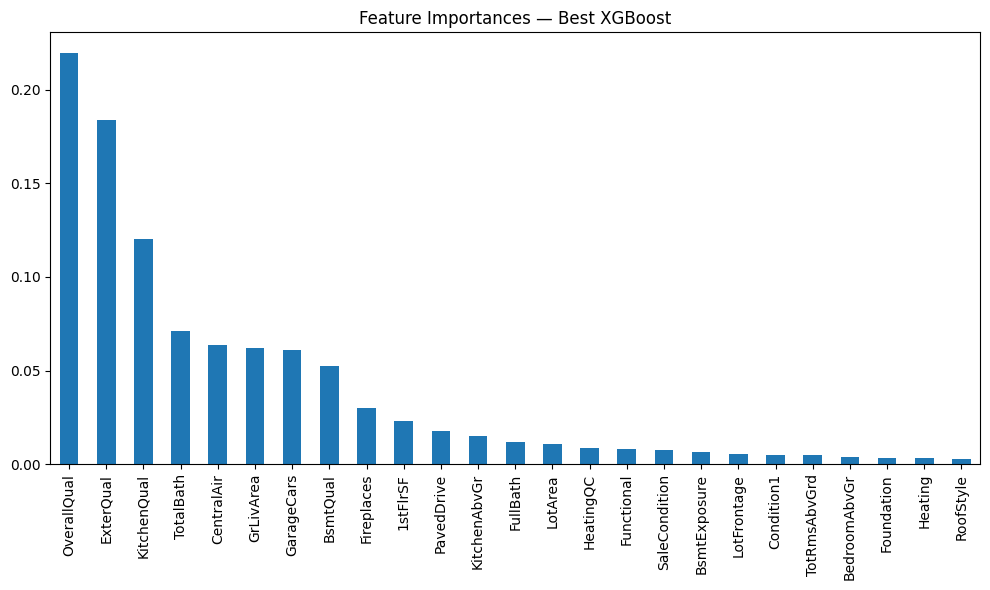

2026/04/12 19:11:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 19:11:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Done!
🏃 View run XGB_best_all_metrics at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/10/runs/88b5b901738a4e7c95f6307d80152af5
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/10


In [36]:
from sklearn.metrics import mean_absolute_error, r2_score

mlflow.set_experiment('best_model_full_metrics')

best_model_full = XGBRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.7,
    random_state=42, n_jobs=-1, verbosity=0
)
best_model_full.fit(X_train_sel, y_train)

train_preds = best_model_full.predict(X_train_sel)
val_preds   = best_model_full.predict(X_val_sel)

with mlflow.start_run(run_name='XGB_best_all_metrics'):
    mlflow.log_param('model', 'XGBoost')
    mlflow.log_param('n_estimators', 300)
    mlflow.log_param('max_depth', 3)
    mlflow.log_param('learning_rate', 0.05)
    mlflow.log_param('subsample', 0.7)
    mlflow.log_param('colsample_bytree', 0.7)

    mlflow.log_metric('train_rmse', rmse(y_train, train_preds))
    mlflow.log_metric('train_mae',  mean_absolute_error(y_train, train_preds))
    mlflow.log_metric('train_r2',   r2_score(y_train, train_preds))

    mlflow.log_metric('val_rmse', rmse(y_val, val_preds))
    mlflow.log_metric('val_mae',  mean_absolute_error(y_val, val_preds))
    mlflow.log_metric('val_r2',   r2_score(y_val, val_preds))

    mlflow.log_metric('overfit_gap', rmse(y_val, val_preds) - rmse(y_train, train_preds))

    feat_imp = pd.Series(best_model_full.feature_importances_, index=X_train_sel.columns)
    feat_imp = feat_imp.sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='bar')
    plt.title('Feature Importances — Best XGBoost')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    mlflow.log_artifact('feature_importance.png')
    plt.show()

    mlflow.sklearn.log_model(best_model_full, 'model')
    print('Done!')

In [43]:
# Linear Regression (no regularization)
from sklearn.linear_model import LinearRegression
mlflow.set_experiment('linear_regression')

lr_params_list = [
    {'fit_intercept': True,  'note': 'baseline'},
    {'fit_intercept': False, 'note': 'no_intercept'},
]

for params in lr_params_list:
    note = params.pop('note')
    model = LinearRegression(**params)
    log_cv_and_test(
        model, 'LinearRegression',
        {'model': 'LinearRegression', **params},
        run_name=f"LR_intercept{params['fit_intercept']}",
        experiment_name='linear_regression',
        note=note
    )
    params['note'] = note

LR_interceptTrue | cv_val_rmse=0.1290 | holdout_val_rmse=0.1369 | note=baseline
🏃 View run LR_interceptTrue at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11/runs/601bbf3508f1479b9086ed11b80c73cd
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11
LR_interceptFalse | cv_val_rmse=0.1796 | holdout_val_rmse=0.1808 | note=no_intercept
🏃 View run LR_interceptFalse at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11/runs/12ace0bd860840dabcdf910fe292abe0
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/11


In [45]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
mlflow.set_experiment('random_forest')

rf_params_list = [
    {'n_estimators': 50,  'max_depth': 3,    'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 3,    'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 1},
    {'n_estimators': 100, 'max_depth': 5,    'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 200, 'max_depth': 15,   'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 15,   'min_samples_leaf': 2},
    {'n_estimators': 300, 'max_depth': 15,   'min_samples_leaf': 4},
    {'n_estimators': 500, 'max_depth': 10,   'min_samples_leaf': 2},
    {'n_estimators': 500, 'max_depth': 15,   'min_samples_leaf': 2},
    {'n_estimators': 500, 'max_depth': 15,   'min_samples_leaf': 4},
    {'n_estimators': 500, 'max_depth': 20,   'min_samples_leaf': 4},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 4},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 1000,'max_depth': 10,   'min_samples_leaf': 2},
]

for params in rf_params_list:
    depth = params['max_depth']
    leaf = params['min_samples_leaf']
    if depth is None and leaf == 1:
        note = 'overfitting'
    elif depth is not None and depth <= 3:
        note = 'underfitting'
    else:
        note = 'ok'
    
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    run_name = f"RF_n{params['n_estimators']}_d{depth}_leaf{leaf}"
    log_cv_and_test(
        model, 'RandomForest',
        {'model': 'RandomForest', **params},
        run_name=run_name,
        experiment_name='random_forest',
        note=note
    )

RF_n50_d3_leaf1 | cv_val_rmse=0.1922 | holdout_val_rmse=0.1947 | note=underfitting
🏃 View run RF_n50_d3_leaf1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12/runs/c189151621ba4d6b8dcad6a07b7ddfc8
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12
RF_n100_d3_leaf1 | cv_val_rmse=0.1920 | holdout_val_rmse=0.1937 | note=underfitting
🏃 View run RF_n100_d3_leaf1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12/runs/b8982a25c4614844b2e9377d15627b35
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12
RF_n100_d5_leaf1 | cv_val_rmse=0.1580 | holdout_val_rmse=0.1632 | note=ok
🏃 View run RF_n100_d5_leaf1 at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12/runs/d98ad3247487437b89279e368ac1b0dc
🧪 View experiment at: https://dagshub.com/sophyrise/house-prices-mlflow.mlflow/#/experiments/12
RF_n100_d5_leaf2 | cv_val_rmse=0.1582 | 

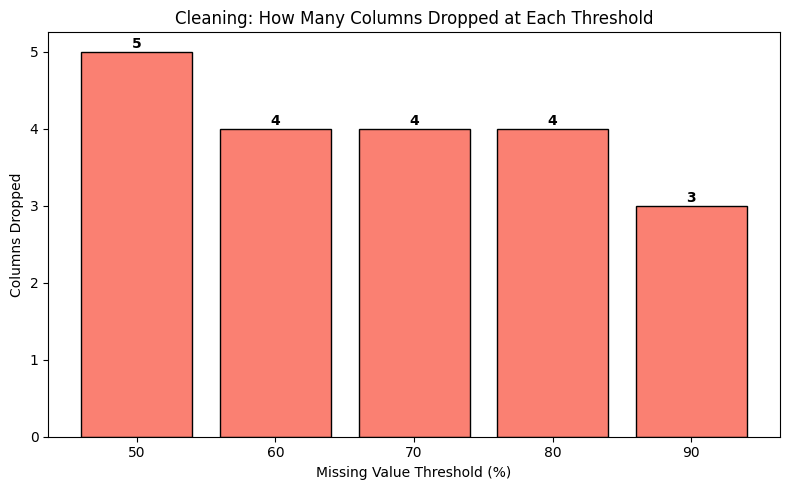

Saved: cleaning_threshold.png


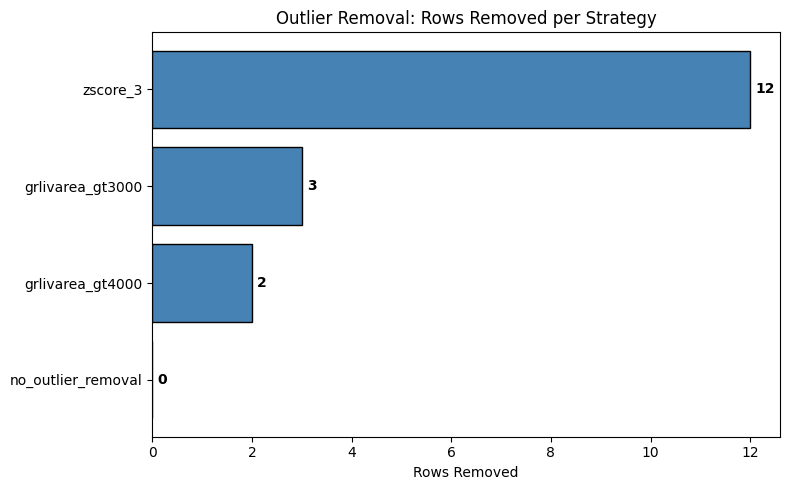

Saved: outlier_removal.png


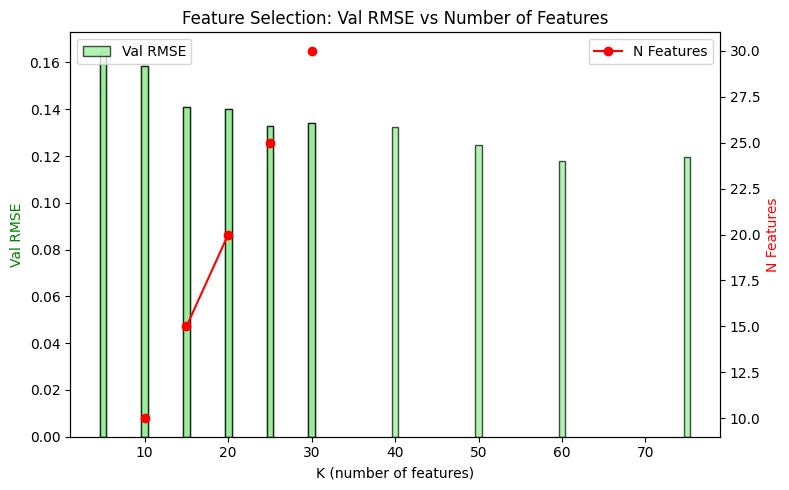

Saved: feature_selection.png


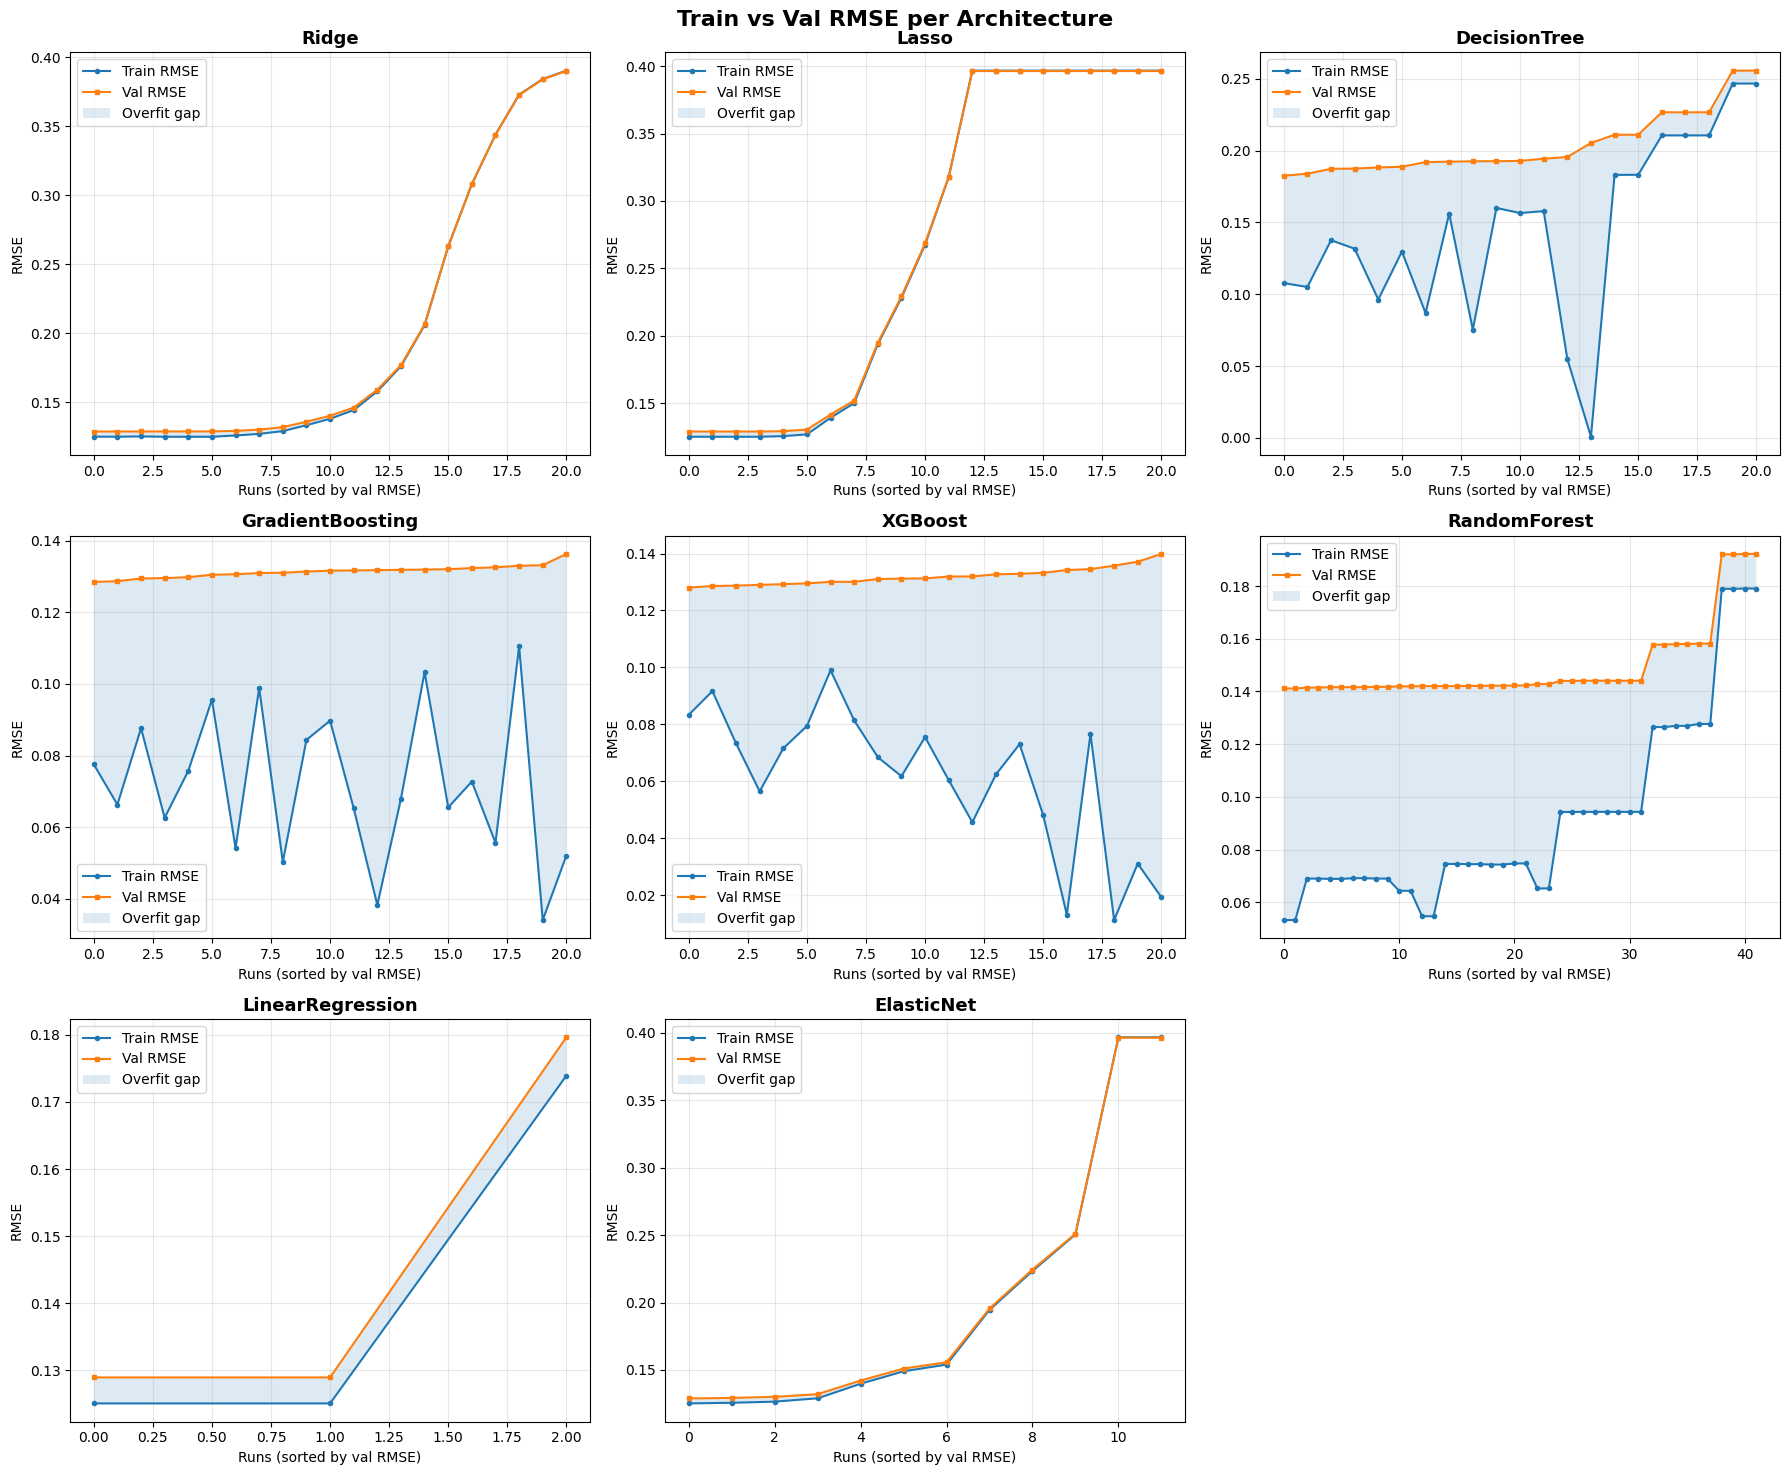

Saved: architecture_comparison.png


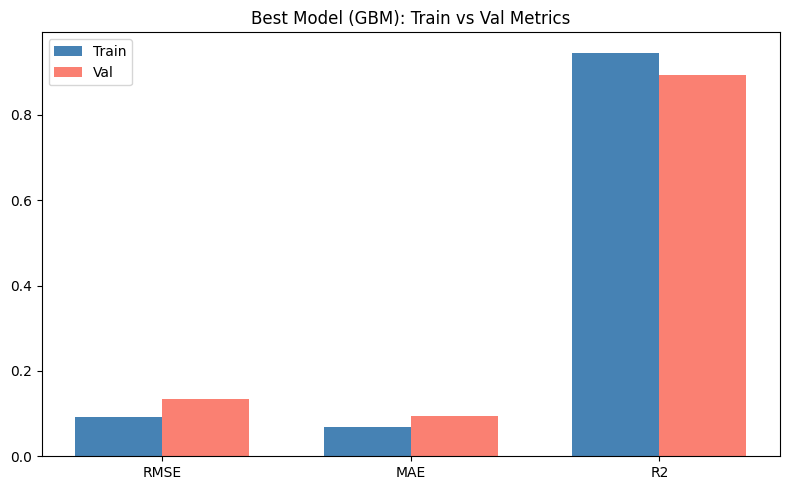

Saved: best_model_metrics.png


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CLEANING THRESHOLD GRAPH
cleaning_runs = mlflow.search_runs(experiment_names=['cleaning_experiments'])
threshold_runs = cleaning_runs[cleaning_runs['tags.mlflow.runName'].str.startswith('cleaning_threshold')]
threshold_runs = threshold_runs.sort_values('params.missing_threshold_pct')

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(threshold_runs['params.missing_threshold_pct'],
       threshold_runs['metrics.n_cols_dropped'], color='salmon', edgecolor='black')
ax.set_xlabel('Missing Value Threshold (%)')
ax.set_ylabel('Columns Dropped')
ax.set_title('Cleaning: How Many Columns Dropped at Each Threshold')
for i, (x, y) in enumerate(zip(threshold_runs['params.missing_threshold_pct'],
                                threshold_runs['metrics.n_cols_dropped'])):
    ax.text(x, y + 0.05, str(int(y)), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cleaning_threshold.png', dpi=150)
plt.show()
print('Saved: cleaning_threshold.png')

# 2. OUTLIER REMOVAL GRAPH
outlier_runs = cleaning_runs[cleaning_runs['tags.mlflow.runName'].str.startswith('outlier_')]
outlier_runs = outlier_runs.sort_values('metrics.n_removed')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(outlier_runs['params.strategy'],
        outlier_runs['metrics.n_removed'], color='steelblue', edgecolor='black')
ax.set_xlabel('Rows Removed')
ax.set_title('Outlier Removal: Rows Removed per Strategy')
for i, v in enumerate(outlier_runs['metrics.n_removed']):
    ax.text(v + 0.1, i, str(int(v)), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_removal.png', dpi=150)
plt.show()
print('Saved: outlier_removal.png')

# 3. FEATURE SELECTION GRAPH
fs_runs = mlflow.search_runs(experiment_names=['feature_selection_experiments'])
fs_runs = fs_runs[fs_runs['tags.mlflow.runName'].str.startswith('SelectKBest')]
fs_runs = fs_runs.dropna(subset=['params.k'])
fs_runs['k'] = fs_runs['params.k'].astype(int)
fs_runs = fs_runs.sort_values('k')

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()
ax1.bar(fs_runs['k'], fs_runs['metrics.val_rmse'],
        color='lightgreen', edgecolor='black', alpha=0.7, label='Val RMSE')
ax2.plot(fs_runs['k'], fs_runs['metrics.n_features'],
         color='red', marker='o', label='N Features')
ax1.set_xlabel('K (number of features)')
ax1.set_ylabel('Val RMSE', color='green')
ax2.set_ylabel('N Features', color='red')
ax1.set_title('Feature Selection: Val RMSE vs Number of Features')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150)
plt.show()
print('Saved: feature_selection.png')

# 4. ARCHITECTURE COMPARISON GRAPH
all_runs = mlflow.search_runs(
    experiment_names=['ridge_regression', 'lasso_regression', 'decision_tree',
                      'gradient_boosting', 'xgboost', 'random_forest',
                      'linear_regression', 'elasticnet'],
    order_by=['metrics.val_rmse ASC']
)

architectures = {
    'Ridge':            'Ridge',
    'Lasso':            'Lasso',
    'DecisionTree':     'DecisionTree',
    'GradientBoosting': 'GradientBoosting',
    'XGBoost':          'XGBoost',
    'RandomForest':     'RandomForest',
    'LinearRegression': 'LinearRegression',
    'ElasticNet':       'ElasticNet',
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (model_name, param_val) in enumerate(architectures.items()):
    runs = all_runs[all_runs['params.model'] == param_val].copy()
    runs = runs.dropna(subset=['metrics.train_rmse', 'metrics.val_rmse'])
    runs = runs.sort_values('metrics.val_rmse')
    x = range(len(runs))

    ax = axes[i]
    if len(runs) == 0:
        ax.set_title(f'{model_name} (no data)', fontsize=11)
        continue
    ax.plot(x, runs['metrics.train_rmse'].values, label='Train RMSE', marker='o', markersize=3)
    ax.plot(x, runs['metrics.val_rmse'].values,   label='Val RMSE',   marker='s', markersize=3)
    ax.fill_between(x,
                    runs['metrics.train_rmse'].values,
                    runs['metrics.val_rmse'].values,
                    alpha=0.15, label='Overfit gap')
    ax.set_title(model_name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Runs (sorted by val RMSE)')
    ax.set_ylabel('RMSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(architectures), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Train vs Val RMSE per Architecture', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: architecture_comparison.png')

# 5. BEST MODEL METRICS GRAPH
metrics_runs = mlflow.search_runs(experiment_names=['best_model_full_metrics'])
best = metrics_runs.iloc[0]

metrics = ['RMSE', 'MAE', 'R2']
train_vals = [best['metrics.train_rmse'], best['metrics.train_mae'], best['metrics.train_r2']]
val_vals   = [best['metrics.val_rmse'],   best['metrics.val_mae'],   best['metrics.val_r2']]

x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, train_vals, width, label='Train', color='steelblue')
ax.bar(x + width/2, val_vals,   width, label='Val',   color='salmon')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Best Model (GBM): Train vs Val Metrics')
ax.legend()
plt.tight_layout()
plt.savefig('best_model_metrics.png', dpi=150)
plt.show()
print('Saved: best_model_metrics.png')

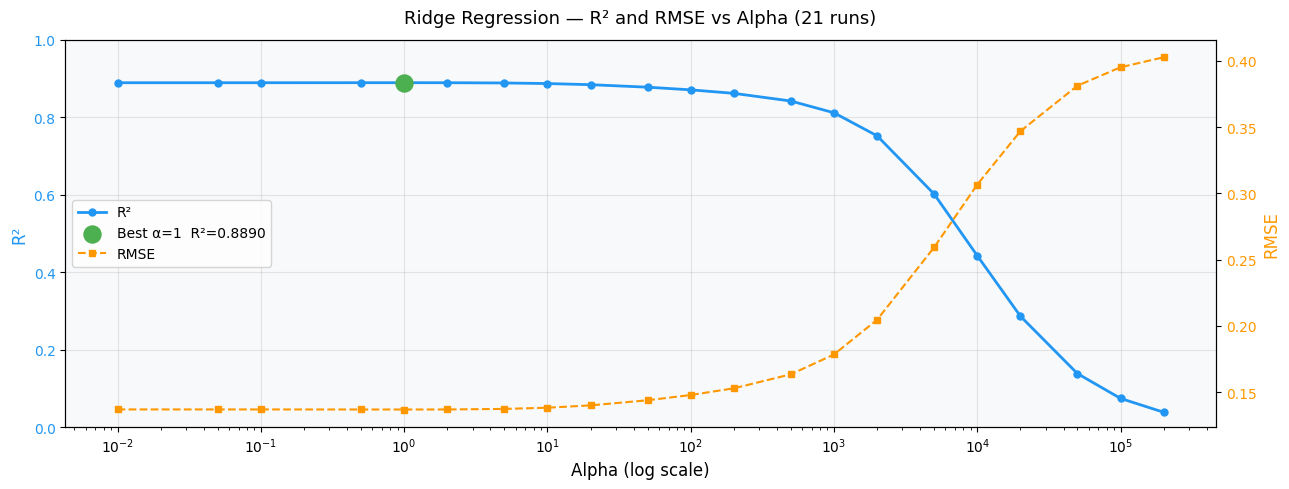

შენახულია: ridge_results.png


In [15]:
import matplotlib.pyplot as plt

runs = client.search_runs(experiment_ids=["3"])
runs = sorted(runs, key=lambda r: float(r.data.params['alpha']))

alphas = [float(r.data.params['alpha']) for r in runs]
r2     = [r.data.metrics['holdout_val_r2']   for r in runs]
rmse   = [r.data.metrics['holdout_val_rmse'] for r in runs]

best_idx = r2.index(max(r2))

fig, ax1 = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('white')
ax1.set_facecolor('#f8f9fa')
ax1.set_xscale('log')

ax1.plot(alphas, r2, color='#2196F3', marker='o', markersize=5, linewidth=2, label='R²')
ax1.scatter([alphas[best_idx]], [r2[best_idx]], color='#4CAF50', s=150, zorder=6,
            label=f'Best α={alphas[best_idx]:.0f}  R²={r2[best_idx]:.4f}')
ax1.set_xlabel('Alpha (log scale)', fontsize=12)
ax1.set_ylabel('R²', color='#2196F3', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(alphas, rmse, color='#FF9800', marker='s', markersize=4,
         linewidth=1.5, linestyle='--', label='RMSE')
ax2.set_ylabel('RMSE', color='#FF9800', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#FF9800')

lines1, labs1 = ax1.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labs1 + labs2, loc='center left', fontsize=10)

plt.title('Ridge Regression — R² and RMSE vs Alpha (21 runs)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('ridge_results.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("შენახულია: ridge_results.png")

In [17]:
for r in runs:
    alpha = float(r.data.params['alpha'])
    print(f"alpha={alpha:<10} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  val_r2={r.data.metrics['val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}")

alpha=0.01       holdout_val_r2=0.888849  val_r2=0.892596  holdout_val_rmse=0.136884
alpha=0.05       holdout_val_r2=0.888858  val_r2=0.892613  holdout_val_rmse=0.136879
alpha=0.1        holdout_val_r2=0.888869  val_r2=0.892632  holdout_val_rmse=0.136872
alpha=0.5        holdout_val_r2=0.888928  val_r2=0.892746  holdout_val_rmse=0.136836
alpha=1.0        holdout_val_r2=0.888952  val_r2=0.892808  holdout_val_rmse=0.136822
alpha=2.0        holdout_val_r2=0.888882  val_r2=0.892769  holdout_val_rmse=0.136864
alpha=5.0        holdout_val_r2=0.888229  val_r2=0.892107  holdout_val_rmse=0.137266
alpha=10.0       holdout_val_r2=0.886735  val_r2=0.890591  holdout_val_rmse=0.138180
alpha=20.0       holdout_val_r2=0.883820  val_r2=0.887661  holdout_val_rmse=0.139947
alpha=50.0       holdout_val_r2=0.877348  val_r2=0.881022  holdout_val_rmse=0.143793
alpha=100.0      holdout_val_r2=0.870490  val_r2=0.873538  holdout_val_rmse=0.147757
alpha=200.0      holdout_val_r2=0.861482  val_r2=0.862806  holdou

In [6]:
import mlflow

mlflow.set_tracking_uri("https://dagshub.com/sophyrise/house-prices-mlflow.mlflow")

client = mlflow.tracking.MlflowClient()

lasso_runs = client.search_runs(experiment_ids=["4"])
lasso_runs = sorted(lasso_runs, key=lambda r: float(r.data.params['alpha']))

for r in lasso_runs:
    alpha = float(r.data.params['alpha'])
    print(f"alpha={alpha:<10} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  val_r2={r.data.metrics['val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}")

alpha=5e-06      holdout_val_r2=0.888858  val_r2=0.892596  holdout_val_rmse=0.136879
alpha=1e-05      holdout_val_r2=0.888868  val_r2=0.892600  holdout_val_rmse=0.136873
alpha=5e-05      holdout_val_r2=0.888944  val_r2=0.892624  holdout_val_rmse=0.136826
alpha=0.0001     holdout_val_r2=0.889028  val_r2=0.892639  holdout_val_rmse=0.136774
alpha=0.0005     holdout_val_r2=0.889171  val_r2=0.892250  holdout_val_rmse=0.136686
alpha=0.001      holdout_val_r2=0.888119  val_r2=0.890441  holdout_val_rmse=0.137334
alpha=0.005      holdout_val_r2=0.868587  val_r2=0.870933  holdout_val_rmse=0.148839
alpha=0.01       holdout_val_r2=0.846731  val_r2=0.851302  holdout_val_rmse=0.160741
alpha=0.05       holdout_val_r2=0.773195  val_r2=0.756407  holdout_val_rmse=0.195535
alpha=0.1        holdout_val_r2=0.698845  val_r2=0.663082  holdout_val_rmse=0.225317
alpha=0.2        holdout_val_r2=0.565630  val_r2=0.538438  holdout_val_rmse=0.270600
alpha=0.3        holdout_val_r2=0.370655  val_r2=0.353460  holdou

In [8]:
for r in elasticnet_runs:
    alpha = float(r.data.params['alpha'])
    l1_ratio = float(r.data.params['l1_ratio'])
    print(f"alpha={alpha:<8} l1_ratio={l1_ratio:<6} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  val_r2={r.data.metrics['val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}")

alpha=0.001    l1_ratio=0.9    holdout_val_r2=0.888369  val_r2=0.890896  holdout_val_rmse=0.137180
alpha=0.001    l1_ratio=0.5    holdout_val_r2=0.889020  val_r2=0.892170  holdout_val_rmse=0.136780
alpha=0.001    l1_ratio=0.1    holdout_val_r2=0.889030  val_r2=0.892746  holdout_val_rmse=0.136773
alpha=0.01     l1_ratio=0.9    holdout_val_r2=0.848134  val_r2=0.853051  holdout_val_rmse=0.160003
alpha=0.01     l1_ratio=0.5    holdout_val_r2=0.867326  val_r2=0.869856  holdout_val_rmse=0.149552
alpha=0.01     l1_ratio=0.1    holdout_val_r2=0.884106  val_r2=0.887634  holdout_val_rmse=0.139774
alpha=0.1      l1_ratio=0.9    holdout_val_r2=0.711603  val_r2=0.676744  holdout_val_rmse=0.220492
alpha=0.1      l1_ratio=0.5    holdout_val_r2=0.769520  val_r2=0.754527  holdout_val_rmse=0.197113
alpha=0.1      l1_ratio=0.1    holdout_val_r2=0.840237  val_r2=0.844100  holdout_val_rmse=0.164110
alpha=1.0      l1_ratio=0.9    holdout_val_r2=-0.000063  val_r2=-0.006676  holdout_val_rmse=0.410593
alpha=1.

In [12]:
dt_runs = client.search_runs(experiment_ids=["5"])

def sort_key(r):
    v = r.data.params.get('max_depth', '0')
    return float(v) if v not in (None, 'None', '') else 0

dt_runs = sorted(dt_runs, key=sort_key)

for r in dt_runs:
    depth = r.data.params.get('max_depth', 'None')
    split = r.data.params.get('min_samples_split')
    leaf  = r.data.params.get('min_samples_leaf')
    print(f"depth={depth:<6} split={split:<4} leaf={leaf:<4} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}  overfit_gap={r.data.metrics['overfit_gap']:.6f}")

depth=None   split=10   leaf=5    holdout_val_r2=0.788334  holdout_val_rmse=0.188897  overfit_gap=0.074800
depth=None   split=2    leaf=1    holdout_val_r2=0.713618  holdout_val_rmse=0.219721  overfit_gap=0.204487
depth=2      split=10   leaf=5    holdout_val_r2=0.632891  holdout_val_rmse=0.248769  overfit_gap=0.008972
depth=2      split=2    leaf=1    holdout_val_r2=0.632891  holdout_val_rmse=0.248769  overfit_gap=0.008972
depth=3      split=10   leaf=5    holdout_val_r2=0.709246  holdout_val_rmse=0.221391  overfit_gap=0.016079
depth=3      split=5    leaf=2    holdout_val_r2=0.709246  holdout_val_rmse=0.221391  overfit_gap=0.016079
depth=3      split=2    leaf=1    holdout_val_r2=0.709246  holdout_val_rmse=0.221391  overfit_gap=0.016079
depth=4      split=5    leaf=2    holdout_val_r2=0.741114  holdout_val_rmse=0.208907  overfit_gap=0.027882
depth=4      split=2    leaf=1    holdout_val_r2=0.741114  holdout_val_rmse=0.208907  overfit_gap=0.027949
depth=5      split=20   leaf=5    hol

In [16]:
for r in rf_runs:
    n_est  = r.data.params.get('n_estimators')
    depth  = r.data.params.get('max_depth')
    leaf   = r.data.params.get('min_samples_leaf')
    print(f"n_est={n_est:<6} depth={depth:<6} leaf={leaf:<4} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}  overfit_gap={r.data.metrics['overfit_gap']:.6f}")

n_est=50     depth=3      leaf=1    holdout_val_r2=0.775123  holdout_val_rmse=0.194702  overfit_gap=0.013114
n_est=100    depth=None   leaf=1    holdout_val_r2=0.871189  holdout_val_rmse=0.147359  overfit_gap=0.087333
n_est=100    depth=10     leaf=1    holdout_val_r2=0.871854  holdout_val_rmse=0.146977  overfit_gap=0.077522
n_est=100    depth=5      leaf=2    holdout_val_r2=0.840919  holdout_val_rmse=0.163760  overfit_gap=0.030507
n_est=100    depth=5      leaf=1    holdout_val_r2=0.841983  holdout_val_rmse=0.163211  overfit_gap=0.031032
n_est=100    depth=3      leaf=1    holdout_val_r2=0.777401  holdout_val_rmse=0.193714  overfit_gap=0.013092
n_est=200    depth=None   leaf=2    holdout_val_r2=0.869161  holdout_val_rmse=0.148514  overfit_gap=0.072739
n_est=200    depth=15     leaf=2    holdout_val_r2=0.868471  holdout_val_rmse=0.148905  overfit_gap=0.072483
n_est=200    depth=10     leaf=2    holdout_val_r2=0.867983  holdout_val_rmse=0.149181  overfit_gap=0.067542
n_est=200    depth=

In [17]:
gb_runs = client.search_runs(experiment_ids=["6"])
gb_runs = sorted(gb_runs, key=lambda r: float(r.data.params.get('n_estimators', 0)))

print(f"სულ runs: {len(gb_runs)}")
for r in gb_runs:
    n_est  = r.data.params.get('n_estimators')
    depth  = r.data.params.get('max_depth')
    lr     = r.data.params.get('learning_rate')
    print(f"n_est={n_est:<6} depth={depth:<6} lr={lr:<6} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}  overfit_gap={r.data.metrics['overfit_gap']:.6f}")

სულ runs: 21
n_est=50     depth=2      lr=0.2    holdout_val_r2=0.875161  holdout_val_rmse=0.145068  overfit_gap=0.022548
n_est=100    depth=3      lr=0.1    holdout_val_r2=0.889158  holdout_val_rmse=0.136694  overfit_gap=0.041910
n_est=100    depth=2      lr=0.2    holdout_val_r2=0.880282  holdout_val_rmse=0.142062  overfit_gap=0.032088
n_est=200    depth=4      lr=0.05   holdout_val_r2=0.883730  holdout_val_rmse=0.140001  overfit_gap=0.063948
n_est=200    depth=3      lr=0.2    holdout_val_r2=0.885345  holdout_val_rmse=0.139026  overfit_gap=0.084256
n_est=200    depth=3      lr=0.1    holdout_val_r2=0.885289  holdout_val_rmse=0.139059  overfit_gap=0.059630
n_est=300    depth=5      lr=0.05   holdout_val_r2=0.881105  holdout_val_rmse=0.141573  overfit_gap=0.099129
n_est=300    depth=4      lr=0.05   holdout_val_r2=0.888025  holdout_val_rmse=0.137391  overfit_gap=0.076509
n_est=300    depth=3      lr=0.05   holdout_val_r2=0.890286  holdout_val_rmse=0.135997  overfit_gap=0.050971
n_est=

In [18]:
xgb_runs = client.search_runs(experiment_ids=["7"])
xgb_runs = sorted(xgb_runs, key=lambda r: float(r.data.params.get('n_estimators', 0)))

print(f"სულ runs: {len(xgb_runs)}")
for r in xgb_runs:
    n_est  = r.data.params.get('n_estimators')
    depth  = r.data.params.get('max_depth')
    lr     = r.data.params.get('learning_rate')
    print(f"n_est={n_est:<6} depth={depth:<6} lr={lr:<6} holdout_val_r2={r.data.metrics['holdout_val_r2']:.6f}  holdout_val_rmse={r.data.metrics['holdout_val_rmse']:.6f}  overfit_gap={r.data.metrics['overfit_gap']:.6f}")

სულ runs: 21
n_est=100    depth=6      lr=0.2    holdout_val_r2=0.866309  holdout_val_rmse=0.150124  overfit_gap=0.120558
n_est=100    depth=3      lr=0.2    holdout_val_r2=0.889054  holdout_val_rmse=0.136758  overfit_gap=0.057851
n_est=200    depth=4      lr=0.2    holdout_val_r2=0.872874  holdout_val_rmse=0.146391  overfit_gap=0.106045
n_est=200    depth=3      lr=0.1    holdout_val_r2=0.890518  holdout_val_rmse=0.135853  overfit_gap=0.055747
n_est=300    depth=3      lr=0.05   holdout_val_r2=0.894830  holdout_val_rmse=0.133151  overfit_gap=0.044681
n_est=300    depth=6      lr=0.1    holdout_val_r2=0.875532  holdout_val_rmse=0.144853  overfit_gap=0.124474
n_est=300    depth=4      lr=0.05   holdout_val_r2=0.886924  holdout_val_rmse=0.138065  overfit_gap=0.071490
n_est=500    depth=5      lr=0.01   holdout_val_r2=0.881737  holdout_val_rmse=0.141196  overfit_gap=0.059820
n_est=500    depth=3      lr=0.05   holdout_val_r2=0.887270  holdout_val_rmse=0.137854  overfit_gap=0.057664
n_est=

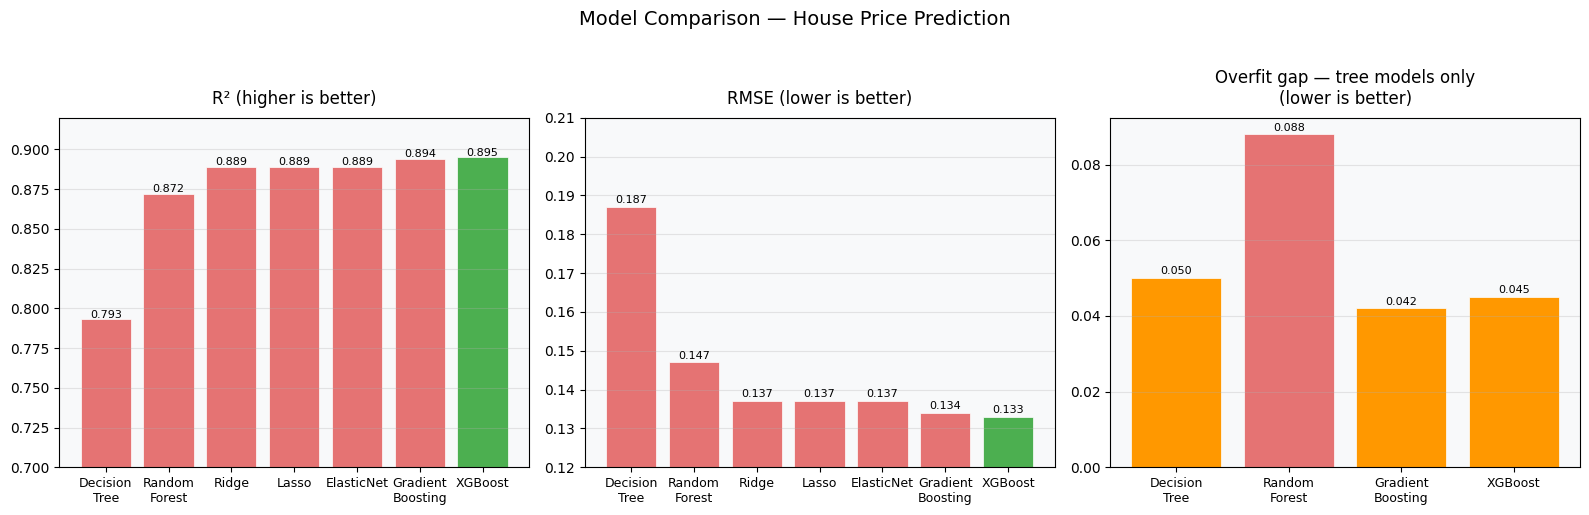

შენახულია: model_comparison.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np

models  = ['Decision\nTree', 'Random\nForest', 'Ridge', 'Lasso', 'ElasticNet', 'Gradient\nBoosting', 'XGBoost']
r2      = [0.793, 0.872, 0.889, 0.889, 0.889, 0.894, 0.895]
rmse    = [0.187, 0.147, 0.137, 0.137, 0.137, 0.134, 0.133]
ovfit   = [0.050, 0.088, None, None, None, 0.042, 0.045]

x = np.arange(len(models))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')

colors = ['#4CAF50' if v == max(r2) else '#E57373' for v in r2]
axes[0].bar(x, r2, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('R² (higher is better)', fontsize=12, pad=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0.7, 0.92)
axes[0].set_facecolor('#f8f9fa')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(r2):
    axes[0].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

colors = ['#4CAF50' if v == min(rmse) else '#E57373' for v in rmse]
axes[1].bar(x, rmse, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('RMSE (lower is better)', fontsize=12, pad=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylim(0.12, 0.21)
axes[1].set_facecolor('#f8f9fa')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(rmse):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

ovfit_models  = ['Decision\nTree', 'Random\nForest', 'Gradient\nBoosting', 'XGBoost']
ovfit_vals    = [0.050, 0.088, 0.042, 0.045]
x2 = np.arange(len(ovfit_models))
colors = ['#FF9800' if v != max(ovfit_vals) else '#E57373' for v in ovfit_vals]
axes[2].bar(x2, ovfit_vals, color=colors, edgecolor='white', linewidth=0.5)
axes[2].set_title('Overfit gap — tree models only\n(lower is better)', fontsize=12, pad=10)
axes[2].set_xticks(x2)
axes[2].set_xticklabels(ovfit_models, fontsize=9)
axes[2].set_facecolor('#f8f9fa')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(ovfit_vals):
    axes[2].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Model Comparison — House Price Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("შენახულია: model_comparison.png")